In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
os.makedirs("../reports", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

In [8]:
def clean_price_series(s):
    s = s.astype(str).str.replace("$", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

def load_listings(filename):
    """
    Limpieza total estilo clase:
    - selección de columnas
    - filtro entire home
    - limpieza de price
    - creación de price_person
    """
    cols = [
        "id", "room_type", "accommodates", "neighbourhood_group_cleansed",
        "price", "first_review", "host_id", "name", "number_of_reviews"
    ]

    # leer solo columnas que existan
    df_cols = pd.read_csv(filename, nrows=0).columns
    use = [c for c in cols if c in df_cols]

    df = pd.read_csv(filename, usecols=use, low_memory=False)

    # filtrar
    df = df.dropna(subset=["first_review"])
    df = df.query("room_type == 'Entire home/apt' & 1 < accommodates < 7")

    # limpiar precio
    df["price"] = clean_price_series(df["price"])

    # precio por persona
    df["price_person"] = df["price"] / df["accommodates"]

    # renombrar area como en clase
    df = df.rename(columns={"neighbourhood_group_cleansed": "area"})

    keep = [
        "id", "host_id", "name", "accommodates",
        "area", "price_person", "number_of_reviews"
    ]
    keep = [c for c in keep if c in df.columns]
    df = df[keep]

    print(f"{filename} shape: {df.shape}")
    return df

In [9]:
bcn_path = "../data/raw/bcn_listings.csv.gz"
other_path = "../data/raw/other_listings.csv.gz"  # opcional

bcn = load_listings(bcn_path)

try:
    other = load_listings(other_path)
except:
    other = None

../data/raw/bcn_listings.csv.gz shape: (8114, 7)


In [17]:
areas = ['Eixample', 'Ciutat Vella', 'Gràcia', 'Sarrià-Sant Gervasi']

pivot = pd.pivot_table(
    bcn.query("area in @areas"),
    index="accommodates",
    columns="area",
    values="price_person",
    aggfunc="median"
)

pivot

area,Ciutat Vella,Eixample,Gràcia,Sarrià-Sant Gervasi
accommodates,,,,
2,38.00,81.000000,61.250000,66.250000
3,30.00,63.666667,60.166667,43.666667
4,32.75,59.000000,47.625000,43.500000
5,38.80,53.200000,41.000000,36.800000
6,50.25,50.000000,40.666667,45.833333


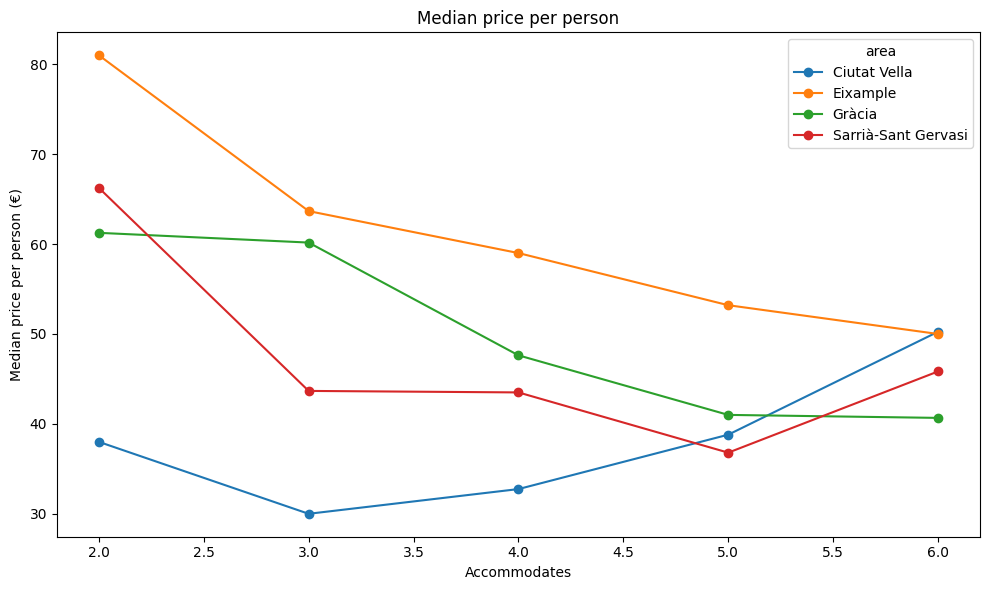

Gráfico guardado en ../reports/graph3.png


In [16]:
ax = pivot.plot(kind="line", marker="o", figsize=(10,6))
ax.set_title("Median price per person")
ax.set_xlabel("Accommodates")
ax.set_ylabel("Median price per person (€)")

plt.tight_layout()
plt.savefig("../reports/graph3.png")
plt.show()

print("Gráfico guardado en ../reports/graph3.png")

In [14]:
import os
os.makedirs("../data/processed", exist_ok=True)

In [15]:
output_path = "../data/processed/clean_bcn_listings.csv"
bcn.to_csv(output_path, index=False)
print(f"Dataset limpio guardado en {output_path}")

Dataset limpio guardado en ../data/processed/clean_bcn_listings.csv
